<a href="https://colab.research.google.com/github/johnisaiah09/FinanceResearch-TCS-/blob/main/Stock_Market_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Imports and loading dataset
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

data_raw = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv")
data = data_raw.copy()

Shape: (6290, 8)
Columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Ticker'],
      dtype='object')
Data types: Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
Ticker        object
dtype: object
Date range: 2019-01-02 to 2023-12-29
Companies: ['AAPL' 'MSFT' 'AMZN' 'GOOGL' 'TSLA']
Rows per company: Ticker
AAPL     1258
MSFT     1258
AMZN     1258
GOOGL    1258
TSLA     1258
Name: count, dtype: int64
Number of invalid rows: 0


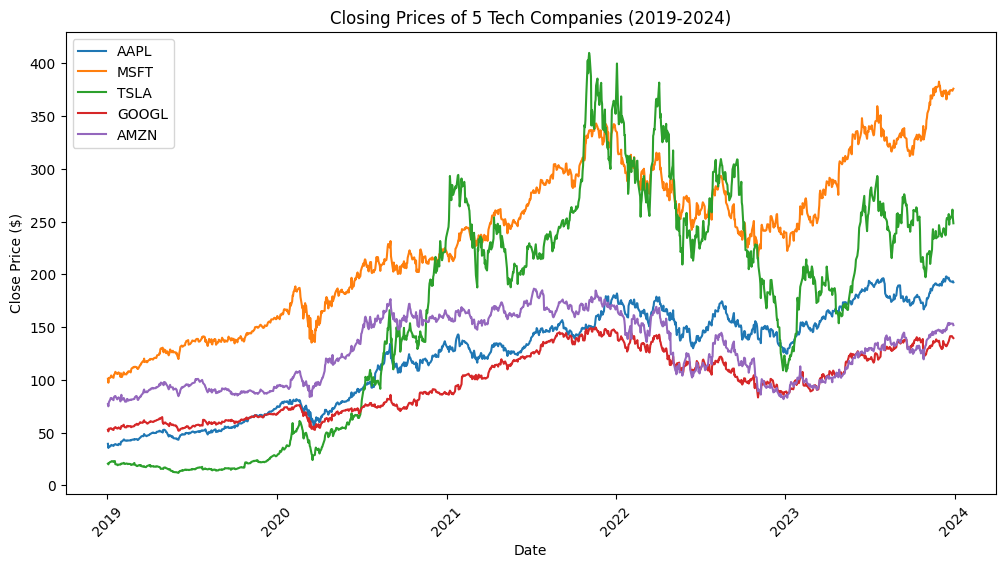

In [3]:
#EDA
print("Shape:", data.shape)
print("Columns:", data.columns)
print("Data types:", data.dtypes)
print("Date range:", data["Date"].min(), "to", data["Date"].max())
print("Companies:", data["Ticker"].unique())
print("Rows per company:", data["Ticker"].value_counts())

# Converting the Date column to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Checking data is sorted
data = data.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)
data.head(10)

# Checking for invalid OHLC rows

invalid_rows = data[
    (data["High"] < data["Open"]) |
    (data["High"] < data["Close"]) |
    (data["High"] < data["Low"]) |
    (data["Low"] > data["Open"]) |
    (data["Low"] > data["Close"])
]

print(f"Number of invalid rows: {len(invalid_rows)}")

# Understanding numerical data
data.describe()

# Summary stats by Company
summary = data.groupby("Ticker").agg(
    {
        "Close": ["mean","std","min","max"],
        "Volume": ["mean","std","min","max"]
    }
)
summary

# Closing Price Visualization
companies = ["AAPL", "MSFT", "TSLA", "GOOGL", "AMZN"]

plt.figure(figsize=(12,6))
for company in companies:
  stock = data[data["Ticker"] == company]
  plt.plot(stock["Date"], stock["Close"], label=company)

plt.title("Closing Prices of 5 Tech Companies (2019-2024)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.xticks(rotation=45)
plt.show()




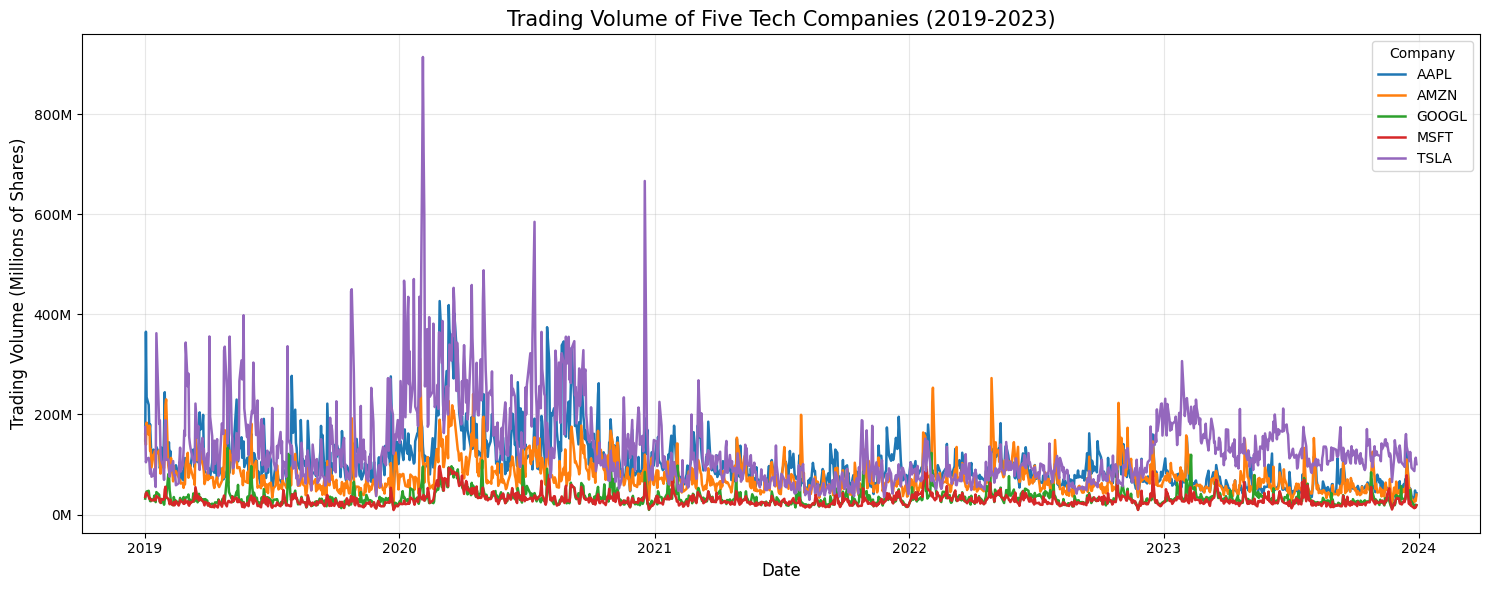

In [4]:
# Trading Volume Visualization
plt.figure(figsize=(15,6))

for ticker in data["Ticker"].unique():
  company = data[data["Ticker"] == ticker]
  plt.plot(
      company["Date"],
      company["Volume"],
      linewidth=1.8,
      label = ticker
  )

plt.title("Trading Volume of Five Tech Companies (2019-2023)", fontsize=15)
plt.xlabel("Date",fontsize=12)
plt.ylabel("Trading Volume (Millions of Shares)", fontsize=12)
plt.grid(True, alpha=0.3)
#Format y-axis in millions instead of sci-notation
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x,pos: f"{x/1e6:.0f}M")
)

plt.legend(title="Company")
plt.tight_layout()
plt.show()

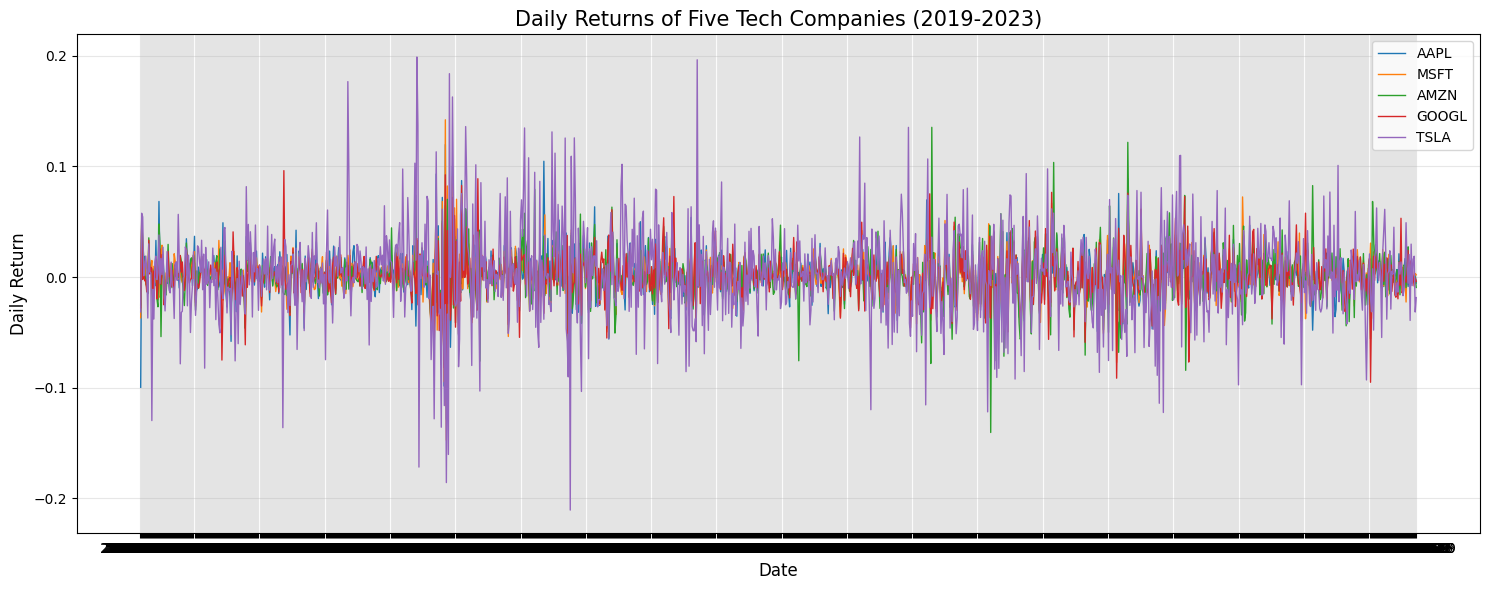

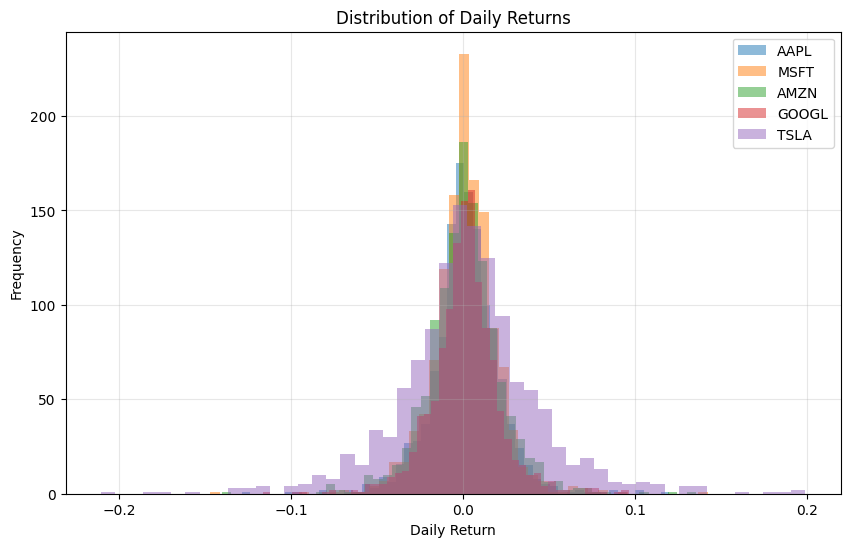

In [14]:
from PIL.Image import linear_gradient
#Daily Returns for each company
data["Daily Return"] = (data.groupby("Ticker")["Close"].pct_change())

plt.figure(figsize=(15,6))

for ticker in data["Ticker"].unique():
  company = data[data["Ticker"] == ticker]

  plt.plot(
      company["Date"],
      company["Daily Return"],
      label=ticker,
      linewidth=1
  )

plt.title("Daily Returns of Five Tech Companies (2019-2023)", fontsize=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Return", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,6))

for ticker in data["Ticker"].unique():
  company = data[data["Ticker"] == ticker]

  plt.hist(
      company["Daily Return"],
      bins=50,
      alpha=0.5,
      label=ticker
  )

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

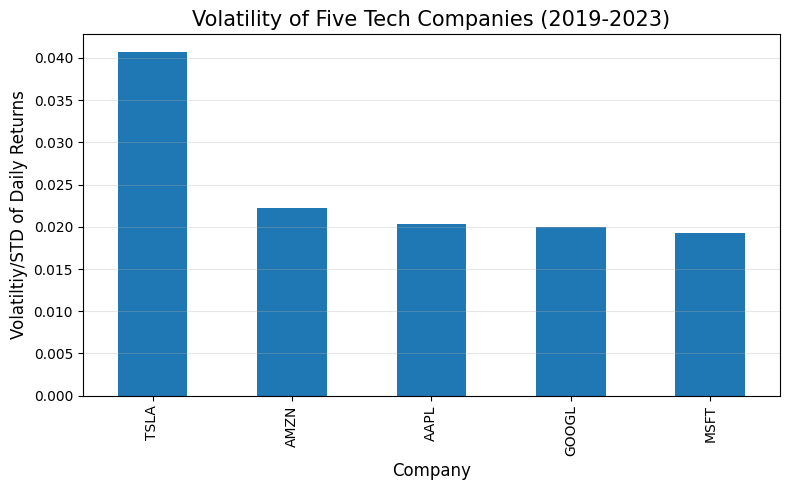

In [12]:
#Volatility
volatility = data.groupby("Ticker")["Daily Return"].std().sort_values(ascending=False)

plt.figure(figsize=(8,5))

volatility.plot(kind="bar")

plt.title("Volatility of Five Tech Companies (2019-2023)", fontsize=15)
plt.xlabel("Company", fontsize=12)
plt.ylabel("Volatiltiy/STD of Daily Returns", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

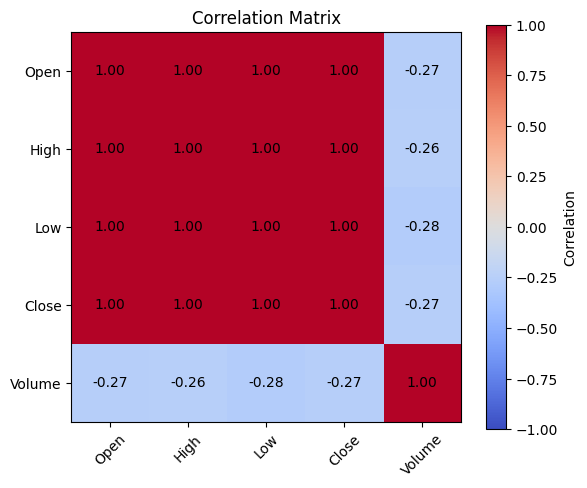

In [8]:
#Correlation

corr = data[["Open", "High", "Low", "Close", "Volume"]].corr()
plt.figure(figsize=(6,5))

plt.imshow(corr,cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)

for i in range(len(corr.columns)):
  for j in range(len(corr.columns)):
    plt.text(
        j,
        i,
        f"{corr.iloc[i,j]:.2f}",
        ha="center",
        va="center",
        color="black"
    )
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

